### How2Sign — re-aligned annotations + frontal keypoints

- **Annotations:** `data/annotations/how2sign_realigned_*.csv` (tab-separated). **Use the same split as your keypoints** (e.g. test CSV with `data/test/frontal`, val CSV with `data/val/frontal`).
- **Keypoints:** any `data/**/frontal/*.npy` — stem matches `SENTENCE_NAME` or `SENTENCE_ID`, or `*_holistic` for raw dumps.

The plot cell searches **all** `data/**/frontal` folders. If nothing matches the CSV, it plots the first `.npy` it finds and prints a warning (or set `MANUAL_NPY_PATH` in that cell).

Run: load CSV → overlap stats → plot.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path(".")
CSV_PATH = ROOT / "data/annotations/how2sign_realigned_test.csv"
# Prefer the split that matches your CSV (val annotations → val/frontal, test → test/frontal).
FRONTAL_DIR = ROOT / "data/test/frontal"

df_val = pd.read_csv(CSV_PATH, sep="\t", dtype=str, keep_default_na=False)
df_val.columns = [c.strip() for c in df_val.columns]

print("Columns:", list(df_val.columns))
print("Rows:", len(df_val))
display(df_val.head())

# All keypoint clips anywhere under data/**/frontal/
def _stem_key(p: Path) -> str:
    s = p.stem
    return s[: -len("_holistic")] if s.endswith("_holistic") else s


npy_files = sorted(ROOT.glob("data/**/frontal/*.npy"))
stem_set = {_stem_key(p) for p in npy_files}

sentences_csv = set(df_val["SENTENCE_NAME"].unique())
ids_csv = set(df_val["SENTENCE_ID"].unique())
overlap = (sentences_csv | ids_csv) & stem_set
print(f"\nFrontal .npy files (any split): {len(npy_files)}")
if npy_files:
    dirs = sorted({p.parent for p in npy_files})
    print("Dirs:", dirs[:12], ("..." if len(dirs) > 12 else ""))
print(f"Unique SENTENCE_NAME in CSV: {len(sentences_csv)}")
print(f"SENTENCE_NAME or SENTENCE_ID with a matching .npy stem: {len(overlap)}")
if len(overlap) == 0 and len(npy_files) > 0:
    print(
        "\nNo overlap: your CSV split may not match the keypoint folder "
        "(e.g. val CSV vs test/frontal). Use matching CSV + frontal, or set MANUAL_NPY_PATH in the plot cell."
    )
    print("Example .npy stems:", [_stem_key(p) for p in npy_files[:5]])
    print("Example CSV SENTENCE_NAME:", list(sentences_csv)[:3])

Columns: ['VIDEO_ID', 'VIDEO_NAME', 'SENTENCE_ID', 'SENTENCE_NAME', 'START_REALIGNED', 'END_REALIGNED', 'SENTENCE']
Rows: 2357


,VIDEO_ID,VIDEO_NAME,SENTENCE_ID,SENTENCE_NAME,START_REALIGNED,END_REALIGNED,SENTENCE
0,-fZc293MpJk,-fZc293MpJk-1-rgb_front,-fZc293MpJk_0,-fZc293MpJk_0-1-rgb_front,0.26,6.79,Hi!
1,-fZc293MpJk,-fZc293MpJk-1-rgb_front,-fZc293MpJk_2,-fZc293MpJk_2-1-rgb_front,7.27,20.3,The aileron is the control surface in the wing...
2,-fZc293MpJk,-fZc293MpJk-1-rgb_front,-fZc293MpJk_3,-fZc293MpJk_3-1-rgb_front,21.25,25.51,"By moving the stick, you cause pressure to inc..."
3,-fZc293MpJk,-fZc293MpJk-1-rgb_front,-fZc293MpJk_4,-fZc293MpJk_4-1-rgb_front,27.75,44.64,The elevator is the part that moves with the s...
4,-fZc293MpJk,-fZc293MpJk-1-rgb_front,-fZc293MpJk_5,-fZc293MpJk_5-1-rgb_front,46.68,52.44,"Therefore, it's either going uphill, downhill,..."



Frontal .npy files (any split): 1739
Dirs: [PosixPath('data/test/frontal')] 
Unique SENTENCE_NAME in CSV: 2357
SENTENCE_NAME or SENTENCE_ID with a matching .npy stem: 0

No overlap: your CSV split may not match the keypoint folder (e.g. val CSV vs test/frontal). Use matching CSV + frontal, or set MANUAL_NPY_PATH in the plot cell.
Example .npy stems: ['-d5dN54tH2E_0-1-rgb_front', '-d5dN54tH2E_1-1-rgb_front', '-d5dN54tH2E_10-1-rgb_front', '-d5dN54tH2E_11-1-rgb_front', '-d5dN54tH2E_12-1-rgb_front']
Example CSV SENTENCE_NAME: ['G3di9jJTqDs_8-5-rgb_front', 'g3jQ5ecjGz8_2-3-rgb_front', 'G3VM7etNABI_7-5-rgb_front']


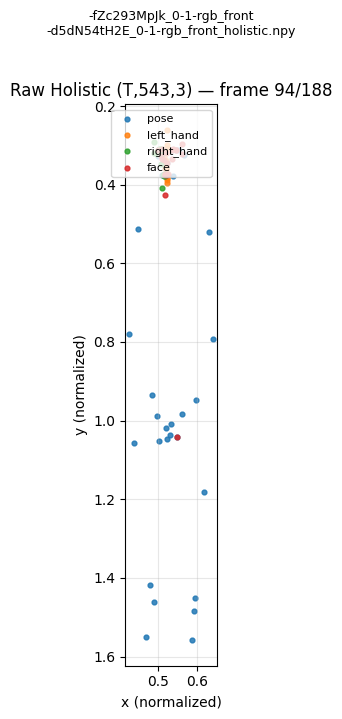

In [10]:
import matplotlib.pyplot as plt

# Set to an int to fix the frame; leave None to use the middle frame.
FRAME_IDX = None

# If automatic matching fails, set this to a concrete file (same split as CSV is best).
MANUAL_NPY_PATH = None  # e.g. Path("data/test/frontal/_fZbAxSSbX4_0-5-rgb_front.npy")

# Layout matches convert_holistic_features.py / PhoenixKeypointExtractor (225-dim processed)
N_POSE, N_LHAND, N_RHAND, N_FACE = 13, 21, 21, 20
FACE_IDX = [61, 291, 0, 17, 39, 269, 181, 405, 70, 63, 105, 300, 293, 334, 33, 133, 263, 362, 1, 2]


def load_keypoints(path: Path) -> np.ndarray:
    arr = np.load(path)
    if arr.ndim == 3 and arr.shape[1:] == (543, 3):
        return arr  # (T, 543, 3) raw Holistic
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D (T,D) or (T,543,3), got {arr.shape} from {path}")
    return arr


def to_joints_75x3(flat: np.ndarray) -> np.ndarray:
    """(D,) with D=225 -> (75, 3)."""
    if flat.shape[0] != 225:
        raise ValueError(f"Expected 225-dim row, got {flat.shape[0]}")
    return flat.reshape(75, 3)


def holistic_to_plot_joints(frame_543x3: np.ndarray) -> dict[str, np.ndarray]:
    """Raw MediaPipe Holistic (543,3) -> groups for 2D plot (x,y)."""
    p = frame_543x3[0:33]
    lh = frame_543x3[33:54]
    rh = frame_543x3[54:75]
    face = frame_543x3[np.array(FACE_IDX)]
    return {"pose": p, "left_hand": lh, "right_hand": rh, "face": face}


def processed_row_to_groups(row225: np.ndarray) -> dict[str, np.ndarray]:
    j = to_joints_75x3(row225)
    return {
        "pose": j[0:N_POSE],
        "left_hand": j[N_POSE : N_POSE + N_LHAND],
        "right_hand": j[N_POSE + N_LHAND : N_POSE + N_LHAND + N_RHAND],
        "face": j[N_POSE + N_LHAND + N_RHAND :],
    }


def discover_frontal_npys():
    return sorted(ROOT.glob("data/**/frontal/*.npy"))


def stem_key(p: Path) -> str:
    s = p.stem
    return s[: -len("_holistic")] if s.endswith("_holistic") else s


def stem_index(paths):
    return {stem_key(p): p for p in paths}


def find_npy_for_row(sentence_name, sentence_id, st_to_path):
    for key in (sentence_name, sentence_id):
        if key in st_to_path:
            return st_to_path[key]
    return None


def find_row_for_npy(npy_path, df):
    sk = stem_key(npy_path)
    for _, r in df.iterrows():
        if r["SENTENCE_NAME"] == sk or r["SENTENCE_ID"] == sk:
            return r
    for _, r in df.iterrows():
        if sk in r["SENTENCE_NAME"] or r["SENTENCE_NAME"] in sk:
            return r
    return None


frontal_npys = discover_frontal_npys()
st_to_path = stem_index(frontal_npys)

row = None
npy_path = None

if MANUAL_NPY_PATH is not None:
    npy_path = Path(MANUAL_NPY_PATH).expanduser()
    if not npy_path.is_absolute():
        npy_path = ROOT / npy_path
    if not npy_path.is_file():
        raise FileNotFoundError(f"MANUAL_NPY_PATH not found: {npy_path}")
    row = find_row_for_npy(npy_path, df_val)
    if row is None:
        row = df_val.iloc[0]
        print("Warning: no CSV row matched that file; caption uses first CSV row.")
else:
    for _, r in df_val.iterrows():
        p = find_npy_for_row(r["SENTENCE_NAME"], r["SENTENCE_ID"], st_to_path)
        if p is not None:
            row, npy_path = r, p
            break
    if row is None and frontal_npys:
        npy_path = frontal_npys[0]
        row = find_row_for_npy(npy_path, df_val)
        if row is None:
            row = df_val.iloc[0]
        print(
            f"Warning: no CSV stem matched any .npy; showing {npy_path.name}. "
            "Use the CSV for the same split as your keypoints (e.g. test CSV + test/frontal)."
        )
    elif row is None:
        raise FileNotFoundError(
            "No .npy files under data/**/frontal/. Download/extract keypoints or set MANUAL_NPY_PATH."
        )

arr = load_keypoints(npy_path)
T = arr.shape[0]
frame_idx = FRAME_IDX if FRAME_IDX is not None else min(T // 2, T - 1)
frame_idx = int(np.clip(frame_idx, 0, T - 1))

if arr.ndim == 3 and arr.shape[1:] == (543, 3):
    groups = holistic_to_plot_joints(arr[frame_idx])
    title = f"Raw Holistic (T,543,3) — frame {frame_idx}/{T-1}"
elif arr.shape[1] == 225:
    groups = processed_row_to_groups(arr[frame_idx])
    title = f"Processed 225-dim keypoints — frame {frame_idx}/{T-1}"
elif arr.shape[1] == 543 * 3:
    j = arr.reshape(T, 543, 3)
    groups = holistic_to_plot_joints(j[frame_idx])
    title = f"Raw Holistic flattened (T,1629) — frame {frame_idx}/{T-1}"
else:
    raise ValueError(f"Unexpected shape {arr.shape} in {npy_path}")

fig, ax = plt.subplots(figsize=(6, 7))
colors = {"pose": "C0", "left_hand": "C1", "right_hand": "C2", "face": "C3"}
for name, pts in groups.items():
    xy = pts[:, :2]
    ax.scatter(xy[:, 0], xy[:, 1], s=12, c=colors[name], label=name, alpha=0.85)

ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.set_xlabel("x (normalized)")
ax.set_ylabel("y (normalized)")
ax.set_title(title)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

clip = row["SENTENCE_NAME"][:60] + ("…" if len(row["SENTENCE_NAME"]) > 60 else "")
fig.suptitle(f"{clip}\n{npy_path.name}", fontsize=9, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Text for the plotted clip (from annotations)
print(row["SENTENCE"][:500])

Hi!


Loaded: _2FBDaOPYig_1-5-rgb_front_holistic.npy  shape=(168, 543, 3)
Frames: 168
Selected: (168, 75, 3) → flattened: (168, 225)


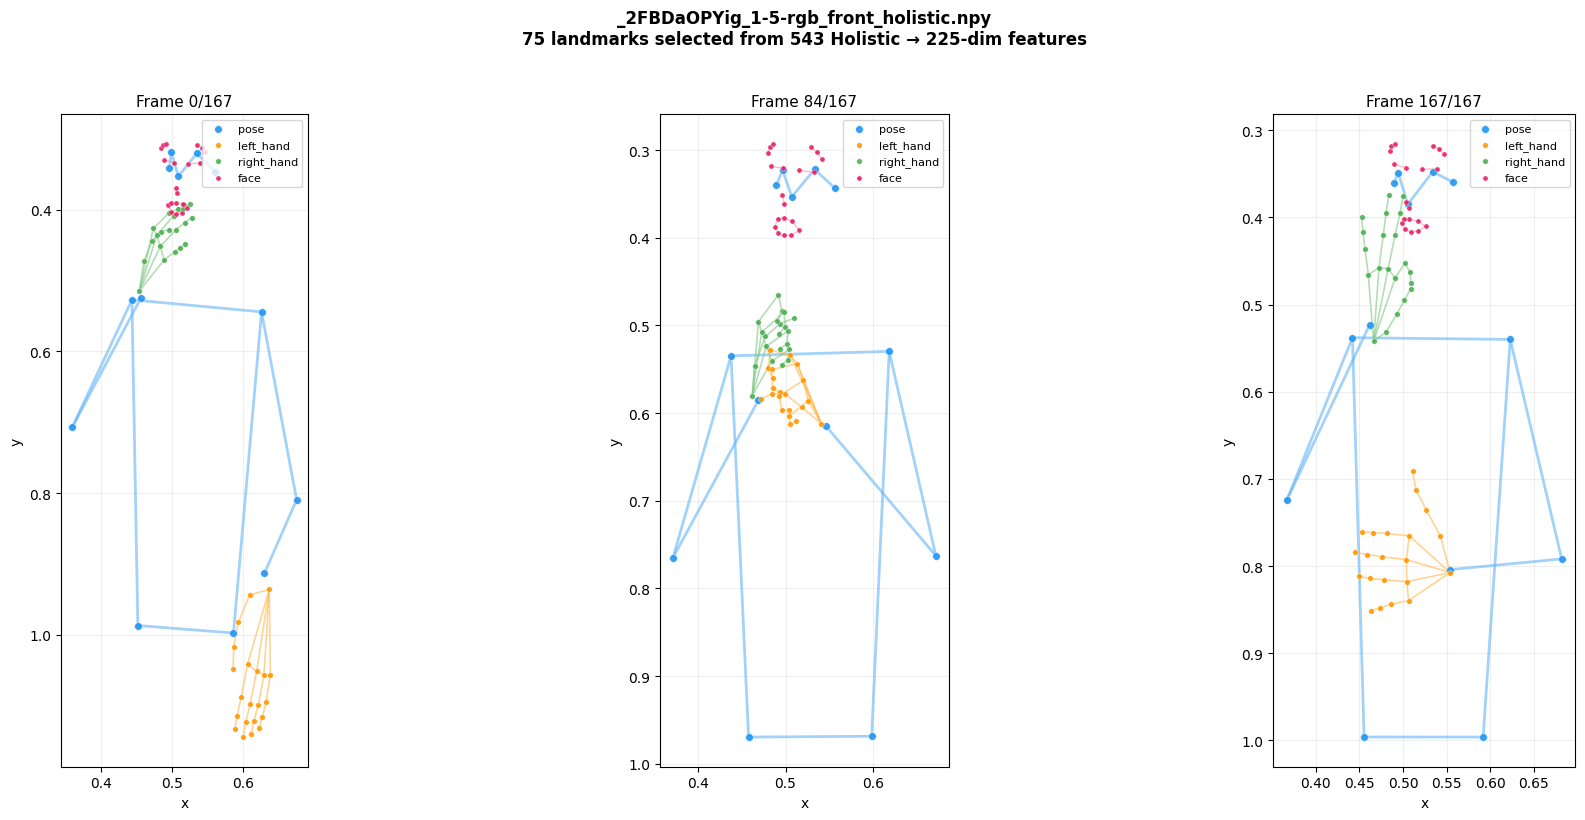

Saved: skeleton_75_from_543.png


In [16]:
"""
Visualize 75 selected landmarks from How2Sign (T, 543, 3) Holistic keypoints.

Selects the same 75 landmarks used in the PHOENIX pipeline:
  13 pose + 21 left hand + 21 right hand + 20 face = 75 joints × 3 coords = 225 features

Draws skeleton connections using matplotlib lines (cleaner than OpenCV for normalized coords).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path

# ─── Landmark selection from 543 Holistic ───────────────────────────
# MediaPipe Holistic layout:
#   Pose:       0 - 32    (33 landmarks)
#   Face:      33 - 500   (468 landmarks)  →  face mesh idx i = holistic idx 33+i
#   Left hand: 501 - 521  (21 landmarks)
#   Right hand:522 - 542  (21 landmarks)

# 13 upper-body pose landmarks (holistic indices)
POSE_SELECT = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24]

# 21 hand landmarks each (holistic indices)
LHAND_SELECT = list(range(501, 522))
RHAND_SELECT = list(range(522, 543))

# 20 face landmarks — face mesh indices mapped to holistic space (33 + mesh_idx)
FACE_MESH_IDS = [
    61, 291, 0, 17, 39, 269, 181, 405,   # lips (8)
    70, 63, 105,                           # left eyebrow (3)
    300, 293, 334,                         # right eyebrow (3)
    33, 133,                               # left eye (2)
    263, 362,                              # right eye (2)
    1, 2,                                  # nose (2)
]
FACE_SELECT = [33 + i for i in FACE_MESH_IDS]

# Combined: 13 + 21 + 21 + 20 = 75
ALL_SELECT = np.array(POSE_SELECT + LHAND_SELECT + RHAND_SELECT + FACE_SELECT)
assert len(ALL_SELECT) == 75, f"Expected 75, got {len(ALL_SELECT)}"

# ─── Group boundaries in the 75-joint array ─────────────────────────
P = len(POSE_SELECT)        # 13
LH = len(LHAND_SELECT)      # 21
RH = len(RHAND_SELECT)      # 21
F = len(FACE_MESH_IDS)      # 20

POSE_RANGE  = (0, P)                              # 0..12
LHAND_RANGE = (P, P + LH)                         # 13..33
RHAND_RANGE = (P + LH, P + LH + RH)               # 34..54
FACE_RANGE  = (P + LH + RH, P + LH + RH + F)      # 55..74

# ─── Skeleton connections (indices into the 75-joint array) ──────────

# Pose connections (indices 0-12 map to selected pose landmarks)
# Selected pose: [nose, l_eye, r_eye, l_ear, r_ear, l_shoulder, r_shoulder,
#                 l_elbow, r_elbow, l_wrist, r_wrist, l_hip, r_hip]
#  idx:            0      1      2      3      4      5          6
#                  7      8      9      10     11     12
POSE_CONNS = [
    (0, 1), (0, 2), (1, 3), (2, 4),       # nose → eyes → ears
    (5, 6),                                 # shoulder span
    (5, 7), (7, 9),                         # left arm
    (6, 8), (8, 10),                        # right arm
    (5, 11), (6, 12),                       # torso sides
    (11, 12),                               # hip span
]

# Hand connections (MediaPipe 21-point hand topology)
# 0=wrist, 1-4=thumb, 5-8=index, 9-12=middle, 13-16=ring, 17-20=pinky
def _hand_conns(offset):
    conns = []
    # wrist to each finger base
    for base in [1, 5, 9, 13, 17]:
        conns.append((offset, offset + base))
    # each finger chain
    for start in [1, 5, 9, 13, 17]:
        for i in range(3):
            conns.append((offset + start + i, offset + start + i + 1))
    # palm connections
    for a, b in [(5, 9), (9, 13), (13, 17)]:
        conns.append((offset + a, offset + b))
    return conns

LHAND_CONNS = _hand_conns(P)           # offset = 13
RHAND_CONNS = _hand_conns(P + LH)      # offset = 34

# Face connections (indices 55-74 in the 75-joint array)
# Lips: 0-7, L-eyebrow: 8-10, R-eyebrow: 11-13, L-eye: 14-15, R-eye: 16-17, Nose: 18-19
FO = P + LH + RH  # face offset = 55
FACE_CONNS = [
    # Lips outline (approximate loop)
    (FO+0, FO+4), (FO+4, FO+2), (FO+2, FO+5), (FO+5, FO+1),  # upper lip
    (FO+0, FO+6), (FO+6, FO+3), (FO+3, FO+7), (FO+7, FO+1),  # lower lip
    # Eyebrows
    (FO+8, FO+9), (FO+9, FO+10),       # left eyebrow
    (FO+11, FO+12), (FO+12, FO+13),    # right eyebrow
    # Eyes
    (FO+14, FO+15),                     # left eye corners
    (FO+16, FO+17),                     # right eye corners
    # Nose bridge
    (FO+18, FO+19),
]

# ─── Extraction function ────────────────────────────────────────────

def select_75_from_543(data_543: np.ndarray) -> np.ndarray:
    """
    Select 75 landmarks from (T, 543, 3) → (T, 75, 3).
    Flatten to (T, 225) for model input.

    Args:
        data_543: np.ndarray of shape (T, 543, 3)
    Returns:
        np.ndarray of shape (T, 75, 3)
    """
    assert data_543.ndim == 3 and data_543.shape[1] == 543 and data_543.shape[2] == 3, \
        f"Expected (T, 543, 3), got {data_543.shape}"
    return data_543[:, ALL_SELECT, :]   # (T, 75, 3)


def select_and_flatten(data_543: np.ndarray) -> np.ndarray:
    """(T, 543, 3) → (T, 225) ready for model input."""
    selected = select_75_from_543(data_543)
    return selected.reshape(selected.shape[0], -1)


# ─── Plotting ───────────────────────────────────────────────────────

COLORS = {
    "pose":       "#2196F3",   # blue
    "left_hand":  "#FF9800",   # orange
    "right_hand": "#4CAF50",   # green
    "face":       "#E91E63",   # pink
}

CONN_COLORS = {
    "pose":       "#64B5F6",
    "left_hand":  "#FFB74D",
    "right_hand": "#81C784",
    "face":       "#F48FB1",
}


def plot_skeleton(joints_75x3: np.ndarray, title: str = "", ax=None):
    """
    Plot 75 landmarks with skeleton connections.

    Args:
        joints_75x3: (75, 3) array — x, y, z coords (only x, y plotted)
        title: plot title
        ax: optional matplotlib Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 8))
    else:
        fig = ax.figure

    xy = joints_75x3[:, :2]

    # ── Draw connections ──
    def draw_conns(conns, color, lw=1.5, alpha=0.6):
        segments = []
        for i, j in conns:
            # skip if either endpoint is zero (missing detection)
            if np.allclose(xy[i], 0) or np.allclose(xy[j], 0):
                continue
            segments.append([xy[i], xy[j]])
        if segments:
            lc = LineCollection(segments, colors=color, linewidths=lw, alpha=alpha)
            ax.add_collection(lc)

    draw_conns(POSE_CONNS, CONN_COLORS["pose"], lw=2.0)
    draw_conns(LHAND_CONNS, CONN_COLORS["left_hand"], lw=1.2)
    draw_conns(RHAND_CONNS, CONN_COLORS["right_hand"], lw=1.2)
    draw_conns(FACE_CONNS, CONN_COLORS["face"], lw=1.0)

    # ── Draw joints ──
    groups = {
        "pose":       xy[POSE_RANGE[0]:POSE_RANGE[1]],
        "left_hand":  xy[LHAND_RANGE[0]:LHAND_RANGE[1]],
        "right_hand": xy[RHAND_RANGE[0]:RHAND_RANGE[1]],
        "face":       xy[FACE_RANGE[0]:FACE_RANGE[1]],
    }
    sizes = {"pose": 30, "left_hand": 16, "right_hand": 16, "face": 14}

    for name, pts in groups.items():
        # skip zero-valued (missing) points
        mask = ~np.all(pts == 0, axis=1)
        if mask.any():
            ax.scatter(pts[mask, 0], pts[mask, 1],
                       s=sizes[name], c=COLORS[name], label=name,
                       alpha=0.9, zorder=5, edgecolors='white', linewidths=0.3)

    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.8)
    ax.grid(True, alpha=0.2)

    return fig, ax


# ─── Main: load, select, plot ───────────────────────────────────────

if __name__ == "__main__":
    import sys

    # Accept path as CLI argument or use a default
    if len(sys.argv) > 1:
        # npy_path = Path(sys.argv[1])
        npy_path = Path("./data/test/frontal/_2FBDaOPYig_1-5-rgb_front_holistic.npy")
    else:
        # Try to find any .npy in common locations
        # candidates = list(Path("./data/test/frontal/").glob("**/*.npy"))
        # if not candidates:
        #     print("Usage: python plot_skeleton.py <path_to_holistic.npy>")
        #     print("  Expected shape: (T, 543, 3)")
        #     sys.exit(1)
        npy_path = Path("./data/test/frontal/_2FBDaOPYig_1-3-rgb_front_holistic.npy")
        print(f"Auto-found: {npy_path}")

    # Load
    raw = np.load(npy_path)
    print(f"Loaded: {npy_path.name}  shape={raw.shape}")

    # Handle different shapes
    if raw.ndim == 3 and raw.shape[1] == 543 and raw.shape[2] == 3:
        data_543 = raw
    elif raw.ndim == 2 and raw.shape[1] == 543 * 3:
        data_543 = raw.reshape(raw.shape[0], 543, 3)
    else:
        print(f"Error: expected (T, 543, 3), got {raw.shape}")
        sys.exit(1)

    T = data_543.shape[0]
    print(f"Frames: {T}")

    # Select 75 landmarks
    selected = select_75_from_543(data_543)  # (T, 75, 3)
    flat = selected.reshape(T, -1)           # (T, 225) — model input
    print(f"Selected: {selected.shape} → flattened: {flat.shape}")

    # Plot 3 frames: first non-zero, middle, last non-zero
    frame_norms = np.linalg.norm(flat, axis=1)
    nonzero = np.where(frame_norms > 0)[0]

    if len(nonzero) == 0:
        print("Warning: all frames are zero!")
        frames_to_show = [0, T // 2, T - 1]
    else:
        frames_to_show = [
            nonzero[0],
            nonzero[len(nonzero) // 2],
            nonzero[-1],
        ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    for ax, fidx in zip(axes, frames_to_show):
        plot_skeleton(
            selected[fidx],
            title=f"Frame {fidx}/{T-1}",
            ax=ax,
        )

    fig.suptitle(
        f"{npy_path.name}\n75 landmarks selected from 543 Holistic → 225-dim features",
        fontsize=12, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig("skeleton_75_from_543.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: skeleton_75_from_543.png")